In [1]:
import os
import sys
import logging
import random
import numpy as np

# Keep Kaggle output readable while TensorFlow initializes.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.FATAL)

import tensorflow as tf

# Fixed seeds make the comparison as reproducible as practical.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# -----------------------------------------------------------------------------
# REPOSITORY CONFIGURATION
# -----------------------------------------------------------------------------
REPO_NAME = "RefraScan"
GITHUB_USER = "KyziaPi"
BRANCH_NAME = "Model-Experiment"  # Change to the branch containing the finalized VSCode code.
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"
REPO_PATH = os.path.join("/kaggle/working", REPO_NAME)

if not os.path.exists(REPO_PATH):
    !env GIT_TERMINAL_PROMPT=0 git clone -b {BRANCH_NAME} {REPO_URL}
else:
    !cd {REPO_PATH} && env GIT_TERMINAL_PROMPT=0 git fetch --all && git checkout {BRANCH_NAME} && git pull origin {BRANCH_NAME}

if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

import sys
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from src.preprocessing import load_and_clean_data, encode_target, validate_dataset
from src.cross_validation import (
    split_holdout_test,
    run_cross_validation,
    train_final_on_development,
    evaluate_holdout_once,
)
from src.models import build_model

Cloning into 'RefraScan'...
remote: Enumerating objects: 580, done.
remote: Total 580 (delta 0), reused 0 (delta 0), pack-reused 580 (from 1)
Receiving objects: 100% (580/580), 54.55 MiB | 31.99 MiB/s, done.
Resolving deltas: 100% (331/331), done.


In [3]:
# -----------------------------------------------------------------------------
# FINAL EXPERIMENT CONFIGURATION
# -----------------------------------------------------------------------------
# Set this ONLY after comparing EfficientNetB3, ResNet50, and DenseNet121
# using their image-only 10-fold CV results.
BEST_MODEL_NAME = "resnet50"  # Change after the controlled comparison.

PREPROCESS_INPUT = {
    "efficientnet": efficientnet_preprocess,
    "resnet50": resnet_preprocess,
    "densenet121": densenet_preprocess,
}[BEST_MODEL_NAME]

DATASET_DIR = '/kaggle/input/datasets/yerikaelainegueco/fundus-images-with-refractive-values'
CSV_PATH = os.path.join(DATASET_DIR, 'RefraScan_dataset.csv')
IMG_DIR = os.path.join(DATASET_DIR, 'FundusImages')

df = load_and_clean_data(CSV_PATH, IMG_DIR)

print("Dataset columns:")
print(df.columns.tolist())
print("\nData origin distribution:")
print(df["data_origin"].value_counts())

df = validate_dataset(df, patient_col="ID", target_col="classification")
df = encode_target(df)

# Recreate the fixed 15% holdout using the same random seed.
development_df, holdout_df = split_holdout_test(
    df, patient_col="ID", target_col="classification_encoded", test_size=0.15
)

print("\nHoldout data origins:")
print(holdout_df["data_origin"].value_counts())

print(f"Selected architecture: {BEST_MODEL_NAME}")

Dataset columns:
['ID', 'sphere', 'cylinder', 'spherical_equivalent', 'age', 'classification', 'eye_side', 'data_origin', 'full_path']

Data origin distribution:
data_origin
AUFMC - Lasik    560
PAPILA           458
Name: count, dtype: int64

DATASET VALIDATION

Total records       : 1,018
Unique patients     : 517
Missing patient IDs : 0
Missing labels      : 0
Duplicate rows      : 0

Class distribution:
classification
Myopia        660
Hyperopia     236
Emmetropia    122
Name: count, dtype: int64

Patients with multiple target classes: 50
These patients have different classifications between their eyes. This is allowed.

Example mixed-class patients:
 ID classification
  2     Emmetropia
  2         Myopia
  4     Emmetropia
  4      Hyperopia
  7     Emmetropia
  7         Myopia
 14         Myopia
 14     Emmetropia
 19     Emmetropia
 19      Hyperopia
 24      Hyperopia
 24     Emmetropia
 27     Emmetropia
 27         Myopia
 34     Emmetropia
 34      Hyperopia
 42     Emmetro

In [4]:
# -----------------------------------------------------------------------------
# PROGRESSIVE FINE-TUNING OF THE SELECTED IMAGE-ONLY ARCHITECTURE
# -----------------------------------------------------------------------------
# Stage 1: unfreeze the upper 10 non-BatchNorm layers.
# Stage 2: expand to the upper 30 non-BatchNorm layers.
# Both stages use the same folds and a low learning rate of 1e-5.

fine_tuned_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=10,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=False,
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/fine_tuning",
    fine_tune=True,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

fine_tuned_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/final_image_only_finetuned_cv_results.csv",
    index=False,
)


PATIENT-LEVEL HOLDOUT SPLIT
Development records : 864
Holdout records     : 154
Development patients: 439
Holdout patients    : 78
Patient overlap     : 0

The holdout set is now untouched and will not be used for architecture/model selection.

RESNET50 | IMAGE ONLY
10-FOLD STRATIFIED GROUP CROSS-VALIDATION

--- Fold 1/10 ---


I0000 00:00:1787979191.793256      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787979191.799765      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/30
 2/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.2969 - loss: 0.7827  

I0000 00:00:1787979212.370973      82 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.4708 - loss: 0.8263
Epoch 1: val_loss improved from None to 0.43112, saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.keras

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 52s 790ms/step - accuracy: 0.5571 - loss: 0.6750 - val_accuracy: 0.7294 - val_loss: 0.4311
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.6601 - loss: 0.4029
Epoch 2: val_loss improved from 0.43112 to 0.36614, saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.keras

Epoch 2: finished saving model to /kaggle/working/RefraScan/artifacts/fine_tuning/resnet50_image_fold_1_frozen.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 36s 740ms/step - accuracy: 0.6418 - loss: 0.4578 - val_accuracy: 0.7176 - val_loss: 0.3661
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.62

In [5]:
# -----------------------------------------------------------------------------
# ABLATION: FUNDUS IMAGE ONLY VS FUNDUS IMAGE + AGE
# -----------------------------------------------------------------------------
# Age is the ONLY additional feature tested here.
# Sphere, cylinder, and spherical equivalent remain excluded because they
# determine the refractive-error target.

age_results = run_cross_validation(
    df=df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    patient_col="ID",
    target_col="classification_encoded",
    n_splits=10,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=True,
    metadata_cols=["age_scaled"],
    output_dir=f"/kaggle/working/{REPO_NAME}/artifacts/age_ablation",
    fine_tune=False,
)

age_results["fold_results"].to_csv(
    f"/kaggle/working/{REPO_NAME}/image_plus_age_cv_results.csv",
    index=False,
)

print("\nCompare the Macro F1 and balanced accuracy means above before choosing the final configuration.")


PATIENT-LEVEL HOLDOUT SPLIT
Development records : 864
Holdout records     : 154
Development patients: 439
Holdout patients    : 78
Patient overlap     : 0

The holdout set is now untouched and will not be used for architecture/model selection.

RESNET50 | IMAGE + AGE
10-FOLD STRATIFIED GROUP CROSS-VALIDATION

--- Fold 1/10 ---
Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.5387 - loss: 0.8116
Epoch 1: val_loss improved from None to 0.47370, saving model to /kaggle/working/RefraScan/artifacts/age_ablation/resnet50_age_fold_1_frozen.keras

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/age_ablation/resnet50_age_fold_1_frozen.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 49s 698ms/step - accuracy: 0.5738 - loss: 0.7403 - val_accuracy: 0.6824 - val_loss: 0.4737
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.6609 - loss: 0.5382
Epoch 2: val_loss improved from 0.47370 to 0.41641, saving model to /kaggle/working/RefraScan/artifacts/age_ablation

=== IMAGE ONLY VS IMAGE + AGE ===
Accuracy: Image Only = 0.7500, Image + Age = 0.7163
Balanced Accuracy: Image Only = 0.6516, Image + Age = 0.6308
Macro F1: Image Only = 0.6190, Image + Age = 0.5795


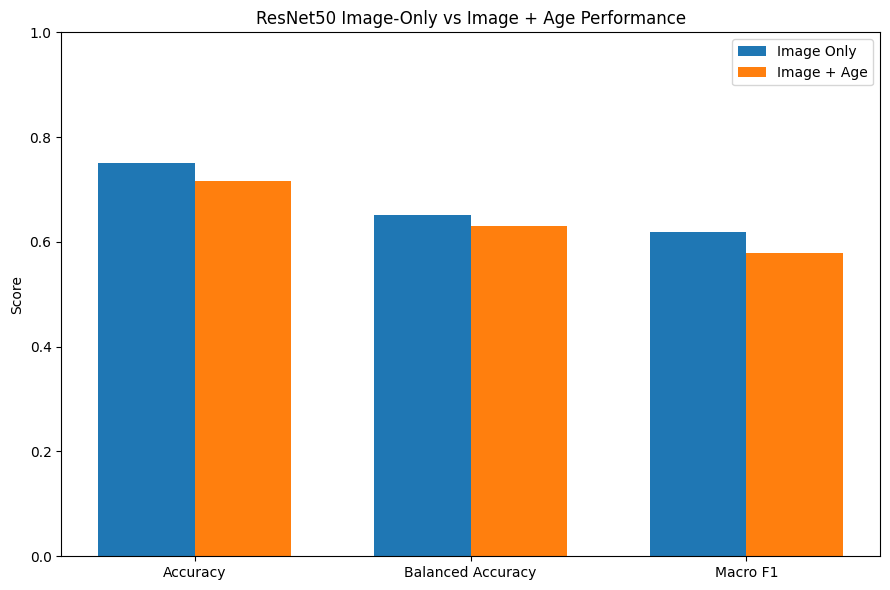

In [6]:
# ============================================================
# VISUALIZATION: IMAGE ONLY VS IMAGE + AGE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Get the actual fold-level results from the CV experiments
image_only_df = fine_tuned_results["fold_results"]
image_age_df = age_results["fold_results"]

# Metrics to visualize
metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1"
]

# Calculate the mean across the actual CV folds
image_only_values = [
    image_only_df["Accuracy"].mean(),
    image_only_df["Balanced Accuracy"].mean(),
    image_only_df["Macro F1"].mean()
]

image_age_values = [
    image_age_df["Accuracy"].mean(),
    image_age_df["Balanced Accuracy"].mean(),
    image_age_df["Macro F1"].mean()
]

# Display the actual values used in the graph
print("=== IMAGE ONLY VS IMAGE + AGE ===")
for metric, image_only, image_age in zip(
    metrics,
    image_only_values,
    image_age_values
):
    print(
        f"{metric}: "
        f"Image Only = {image_only:.4f}, "
        f"Image + Age = {image_age:.4f}"
    )

# ============================================================
# CREATE BAR CHART
# ============================================================

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    x - width / 2,
    image_only_values,
    width,
    label="Image Only"
)

ax.bar(
    x + width / 2,
    image_age_values,
    width,
    label="Image + Age"
)

ax.set_title("ResNet50 Image-Only vs Image + Age Performance")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# -----------------------------------------------------------------------------
# FINAL TRAINING ON ALL 85% DEVELOPMENT DATA
# -----------------------------------------------------------------------------
# At this point the architecture and feature configuration have already been
# selected using development-data CV. The 15% holdout remains untouched.

USE_AGE = True  # Set True only if the image+age ablation is the selected final configuration.
METADATA_COLS = ["age_scaled"] if USE_AGE else None

final_model, final_history = train_final_on_development(
    development_df=development_df,
    model_name=BEST_MODEL_NAME,
    preprocess_input=PREPROCESS_INPUT,
    batch_size=16,
    epochs=30,
    learning_rate=1e-4,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS,
    output_path=f"/kaggle/working/{REPO_NAME}/artifacts/final_model.keras",
    fine_tune=True,
    fine_tune_layers=30,
    fine_tune_epochs=10,
    fine_tune_learning_rate=1e-5,
    fine_tune_stages=[10, 30],
)

print("Final model trained using development data only.")

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.4433 - loss: 0.8570
Epoch 1: saving model to /kaggle/working/RefraScan/artifacts/final_model.keras

Epoch 1: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 413ms/step - accuracy: 0.5312 - loss: 0.6930
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5936 - loss: 0.5489
Epoch 2: saving model to /kaggle/working/RefraScan/artifacts/final_model.keras

Epoch 2: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 381ms/step - accuracy: 0.5984 - loss: 0.5218
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.5763 - loss: 0.5292
Epoch 3: saving model to /kaggle/working/RefraScan/artifacts/final_model.keras

Epoch 3: finished saving model to /kaggle/working/RefraScan/artifacts/final_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 403ms/step - accuracy: 0.6296 - loss: 0.4671
Epoch 4/30

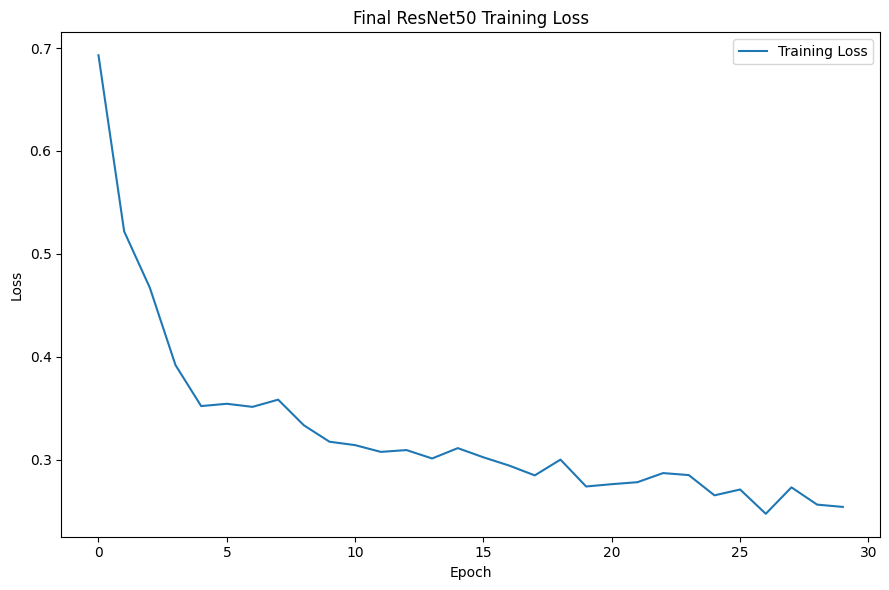

In [8]:
# ============================================================
# VISUALIZATION: FINAL MODEL TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt

history = final_history.history

plt.figure(figsize=(9, 6))

plt.plot(
    history["loss"],
    label="Training Loss"
)

plt.title("Final ResNet50 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

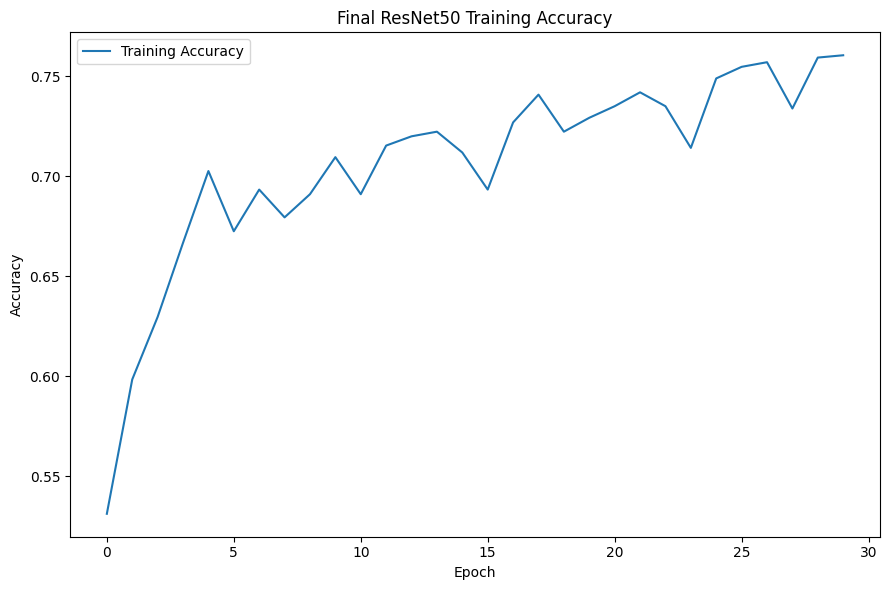

In [9]:
# ============================================================
# VISUALIZATION: FINAL MODEL TRAINING ACCURACY
# ============================================================

import matplotlib.pyplot as plt

history = final_history.history

plt.figure(figsize=(9, 6))

plt.plot(
    history["accuracy"],
    label="Training Accuracy"
)

plt.title("Final ResNet50 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Grad-CAM layer: conv5_block3_out


PAPILA vs AUF-MC PREDICTION RESULTS
prediction_status  Correct  Incorrect
image_source                         
AUF-MC                  68          8
PAPILA                  36         42
PAPILA: 36/78 correct (46.15%)
AUF-MC: 68/76 correct (89.47%)


GRAD-CAM EXAMPLES


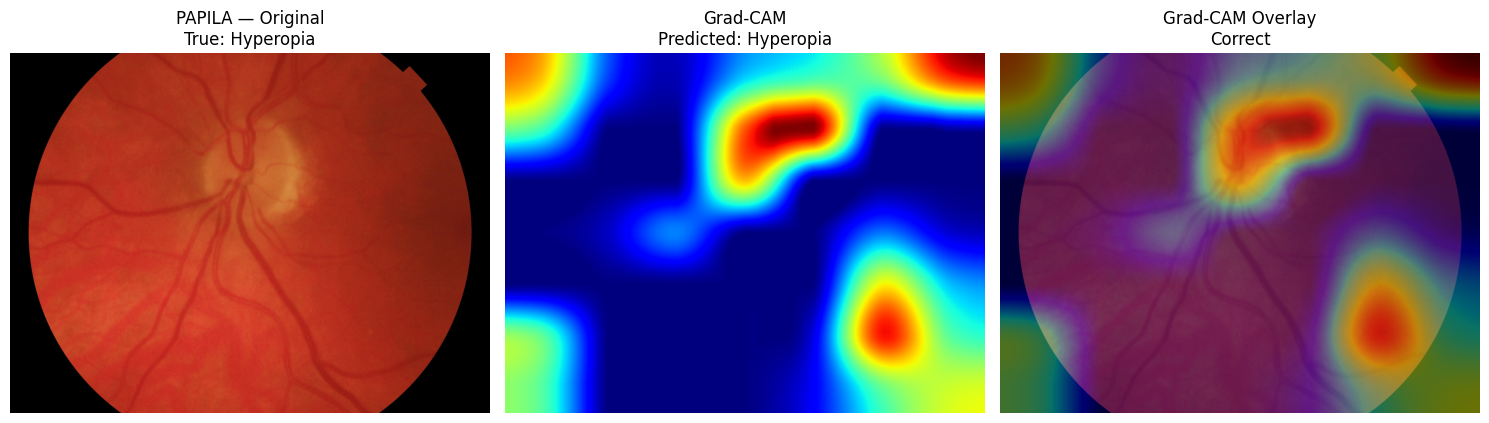

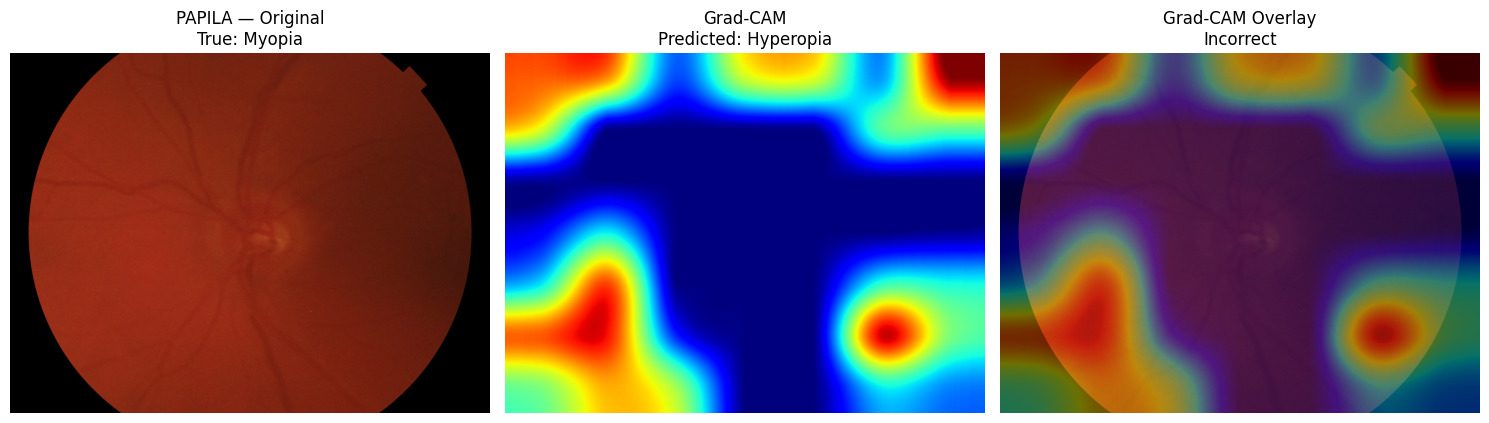

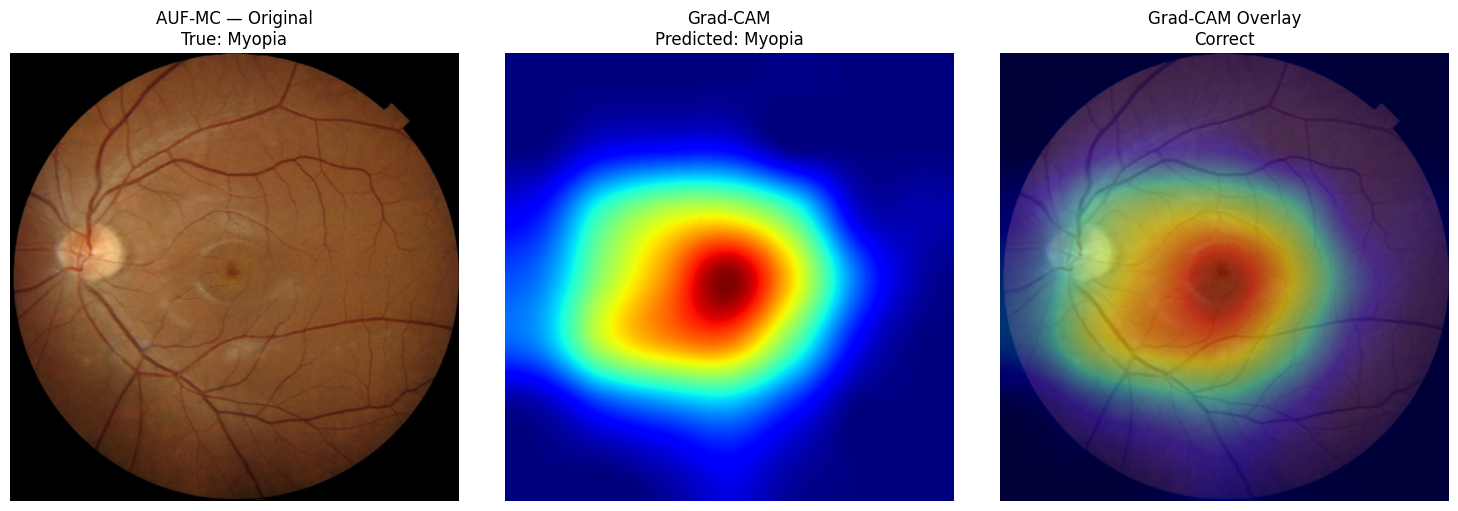

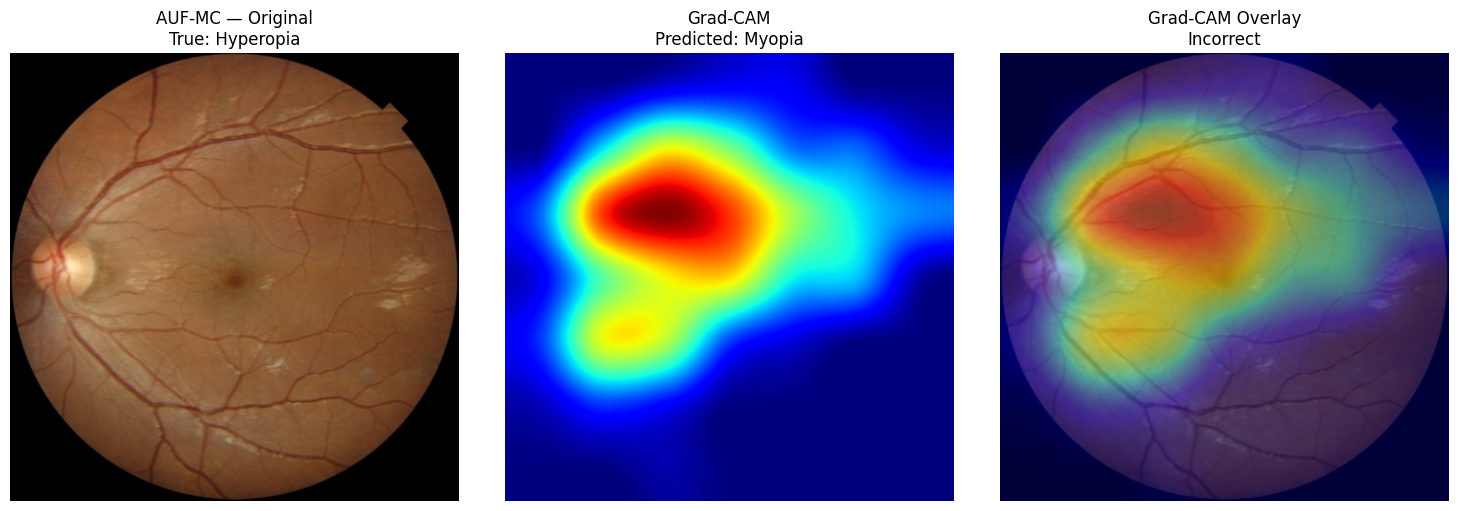

In [10]:
# =============================================================================
# SIMPLE PAPILA vs AUF-MC GRAD-CAM EVALUATION
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------------------------------------------------------
# 1. USE THE FINAL TRAINED RESNET50
# -----------------------------------------------------------------------------
model = final_model

# -----------------------------------------------------------------------------
# 2. USE THE HOLDOUT SET
# -----------------------------------------------------------------------------
gradcam_df = holdout_df.copy()

# Safety check: make sure age_scaled exists if USE_AGE is on, even if
# cell 8 (holdout evaluation) wasn't run first in this kernel session.
if USE_AGE and "age_scaled" not in gradcam_df.columns:
    import joblib
    age_scaler = joblib.load(
        f"/kaggle/working/{REPO_NAME}/artifacts/final_model_age_scaler.joblib"
    )
    gradcam_df["age_scaled"] = age_scaler.transform(gradcam_df[["age"]])

# -----------------------------------------------------------------------------
# 3. IMAGE SOURCE
# -----------------------------------------------------------------------------
gradcam_df["image_source"] = (
    gradcam_df["data_origin"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Normalize source names
gradcam_df["image_source"] = gradcam_df["image_source"].apply(
    lambda x:
        "PAPILA" if "PAPILA" in x
        else "AUF-MC" if "AUF" in x
        else "UNKNOWN"
)

# -----------------------------------------------------------------------------
# 4. CLASS LABELS
# -----------------------------------------------------------------------------
CLASS_NAMES = {
    0: "Emmetropia",
    1: "Myopia",
    2: "Hyperopia"
}

def get_label(value):

    if isinstance(value, (int, np.integer)):
        return int(value)

    value = str(value).strip().lower()

    mapping = {
        "emmetropia": 0,
        "myopia": 1,
        "hyperopia": 2,
        "0": 0,
        "1": 1,
        "2": 2
    }

    return mapping[value]


gradcam_df["true_label"] = (
    gradcam_df["classification"].apply(get_label)
)

# -----------------------------------------------------------------------------
# 5. FIND IMAGE PATH
# -----------------------------------------------------------------------------

if "full_path" in gradcam_df.columns:
    image_column = "full_path"

elif "image_path" in gradcam_df.columns:
    image_column = "image_path"

else:
    raise ValueError(
        "Could not find the image path column."
    )

# -----------------------------------------------------------------------------
# 6. IMAGE PREPROCESSING
# -----------------------------------------------------------------------------
IMAGE_SIZE = (224, 224)

def prepare_image(path):

    img = Image.open(path).convert("RGB")

    original = np.array(img)

    resized = img.resize(IMAGE_SIZE)

    array = np.array(resized).astype(np.float32)

    array = tf.keras.applications.resnet50.preprocess_input(
        array
    )

    return original, array

# -----------------------------------------------------------------------------
# 7. FIND LAST CONVOLUTIONAL LAYER
# -----------------------------------------------------------------------------
def find_last_conv_layer(model):

    for layer in reversed(model.layers):

        try:
            if len(layer.output.shape) == 4:
                return layer.name

        except:
            pass

    raise ValueError(
        "Could not find convolutional layer."
    )


LAST_CONV_LAYER_NAME = find_last_conv_layer(model)

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER_NAME
)

# -----------------------------------------------------------------------------
# 8. PREDICT ALL HOLDOUT IMAGES
# -----------------------------------------------------------------------------
predictions = []

for _, row in gradcam_df.iterrows():

    path = row[image_column]

    _, image_array = prepare_image(path)

    image_batch = np.expand_dims(image_array, axis=0)

    if USE_AGE:
        age_batch = np.array([[row["age_scaled"]]], dtype=np.float32)
        model_input = [image_batch, age_batch]
    else:
        model_input = image_batch

    prediction = model.predict(
        model_input,
        verbose=0
    )[0]

    predictions.append(
        np.argmax(prediction)
    )


gradcam_df["predicted_label"] = predictions

gradcam_df["prediction_status"] = np.where(
    gradcam_df["true_label"]
    ==
    gradcam_df["predicted_label"],
    "Correct",
    "Incorrect"
)

# =============================================================================
# 9. SIMPLE PAPILA vs AUF-MC RESULTS
# =============================================================================
print("\n")
print("=" * 60)
print("PAPILA vs AUF-MC PREDICTION RESULTS")
print("=" * 60)

source_results = (
    gradcam_df[
        gradcam_df["image_source"].isin(
            ["PAPILA", "AUF-MC"]
        )
    ]
    .groupby(
        ["image_source", "prediction_status"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(source_results)

# -----------------------------------------------------------------------------
# 10. PERCENTAGE OF CORRECT PREDICTIONS
# -----------------------------------------------------------------------------

for source in ["PAPILA", "AUF-MC"]:

    subset = gradcam_df[
        gradcam_df["image_source"] == source
    ]

    correct = (
        subset["prediction_status"] == "Correct"
    ).sum()

    total = len(subset)

    accuracy = (
        correct / total * 100
        if total > 0 else 0
    )

    print(
        f"{source}: "
        f"{correct}/{total} correct "
        f"({accuracy:.2f}%)"
    )

# =============================================================================
# 11. GRAD-CAM FUNCTION
# =============================================================================

def make_gradcam(
    image_array,
    model,
    layer_name,
    class_index,
    age_value=None
):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    image_tensor = tf.expand_dims(
        image_array,
        axis=0
    )

    if age_value is not None:
        age_tensor = tf.constant(
            [[age_value]], dtype=tf.float32
        )
        model_input = [image_tensor, age_tensor]
    else:
        model_input = image_tensor

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            model_input
        )

        class_output = predictions[:, class_index]

    gradients = tape.gradient(
        class_output,
        conv_outputs
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = (
        conv_outputs
        @ pooled_gradients[..., tf.newaxis]
    )

    heatmap = tf.squeeze(
        heatmap
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(
        heatmap
    )

    if max_value > 0:
        heatmap /= max_value

    return heatmap.numpy()

# =============================================================================
# 12. SELECT REPRESENTATIVE IMAGES
# =============================================================================
selected = []

for source in ["PAPILA", "AUF-MC"]:

    for status in ["Correct", "Incorrect"]:

        candidates = gradcam_df[
            (gradcam_df["image_source"] == source)
            &
            (gradcam_df["prediction_status"] == status)
        ]

        if len(candidates) > 0:

            selected.append(
                candidates.sample(
                    n=1,
                    random_state=42
                ).iloc[0]
            )

# =============================================================================
# 13. DISPLAY GRAD-CAM RESULTS
# =============================================================================
print("\n")
print("=" * 60)
print("GRAD-CAM EXAMPLES")
print("=" * 60)

for row in selected:

    path = row[image_column]
    original, image_array = prepare_image(
        path
    )

    predicted_class = int(
        row["predicted_label"]
    )

# Generate Grad-CAM
    heatmap = make_gradcam(
        image_array,
        model,
        LAST_CONV_LAYER_NAME,
        predicted_class,
        age_value=row["age_scaled"] if USE_AGE else None
    )

# Resize heatmap to original image dimensions
    heatmap_image = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize(
        (original.shape[1], original.shape[0])
    )

    heatmap_array = np.array(
        heatmap_image
    )

# -------------------------------------------------------------------------
# DISPLAY: ORIGINAL | GRAD-CAM | OVERLAY
# -------------------------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

# 1. ORIGINAL IMAGE

    axes[0].imshow(original)

    axes[0].set_title(
        f"{row['image_source']} — Original\n"
        f"True: {CLASS_NAMES[row['true_label']]}"
    )

    axes[0].axis("off")

# 2. GRAD-CAM HEATMAP

    axes[1].imshow(
        heatmap_array,
        cmap="jet"
    )

    axes[1].set_title(
        f"Grad-CAM\n"
        f"Predicted: {CLASS_NAMES[predicted_class]}"
    )

    axes[1].axis("off")

 # 3. GRAD-CAM OVERLAY

    axes[2].imshow(original)

    axes[2].imshow(
        heatmap_array,
        cmap="jet",
        alpha=0.45
    )

    axes[2].set_title(
        f"Grad-CAM Overlay\n"
        f"{row['prediction_status']}"
    )

    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

In [11]:
# -----------------------------------------------------------------------------
# FINAL HOLDOUT EVALUATION -- RUN THIS CELL ONCE
# -----------------------------------------------------------------------------
# Do NOT rerun this evaluation to make additional architecture/hyperparameter
# decisions. The holdout is the final unbiased estimate.
if USE_AGE:
    import joblib
    age_scaler = joblib.load(
        f"/kaggle/working/{REPO_NAME}/artifacts/final_model_age_scaler.joblib"
    )
    holdout_df["age_scaled"] = age_scaler.transform(holdout_df[["age"]])

final_holdout_result = evaluate_holdout_once(
    model=final_model,
    holdout_df=holdout_df,
    preprocess_input=PREPROCESS_INPUT,
    batch_size=16,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS,
    model_name=BEST_MODEL_NAME,
)


--- Running Inference ---

--- Classification Report ---
              precision    recall  f1-score   support

  Emmetropia       0.36      0.15      0.21        27
      Myopia       0.82      0.77      0.80        88
   Hyperopia       0.50      0.77      0.61        39

    accuracy                           0.66       154
   macro avg       0.56      0.56      0.54       154
weighted avg       0.66      0.66      0.64       154

--- Evaluation Metrics ---
Accuracy          : 0.6623
Balanced Accuracy : 0.5634
Macro Precision   : 0.5610
Macro Recall      : 0.5634
Macro F1          : 0.5373

Confusion Matrix:
[[ 4  6 17]
 [ 7 68 13]
 [ 0  9 30]]

*** FINAL HOLDOUT EVALUATION COMPLETED ONCE ***


In [12]:
# ============================================================
# FINAL HOLDOUT PREDICTIONS FOR VISUALIZATION ONLY
# ============================================================

import numpy as np
import tensorflow as tf

# Use the SAME final model and untouched holdout dataframe.
# This is inference only for creating the visualization.

def make_holdout_dataset_for_visualization(
    dataframe,
    image_size,
    preprocess_input,
    use_metadata,
    metadata_cols
):
    image_paths = dataframe["full_path"].values
    labels = dataframe["classification_encoded"].values

    images = []

    for path in image_paths:
        image = tf.keras.utils.load_img(
            path,
            target_size=image_size
        )
        image = tf.keras.utils.img_to_array(image)
        image = preprocess_input(image)
        images.append(image)

    images = np.asarray(images, dtype=np.float32)

    if use_metadata:
        metadata = dataframe[metadata_cols].values.astype(np.float32)
        return (images, metadata), labels

    return images, labels


# ResNet50 uses 224 x 224 according to the final configuration
holdout_inputs, y_true = make_holdout_dataset_for_visualization(
    holdout_df,
    image_size=(224, 224),
    preprocess_input=PREPROCESS_INPUT,
    use_metadata=USE_AGE,
    metadata_cols=METADATA_COLS
)

# Generate predictions using the CURRENT final model
y_prob = final_model.predict(
    holdout_inputs,
    batch_size=16,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

print("Holdout samples:", len(y_true))
print("Predictions:", len(y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step
Holdout samples: 154
Predictions: 154


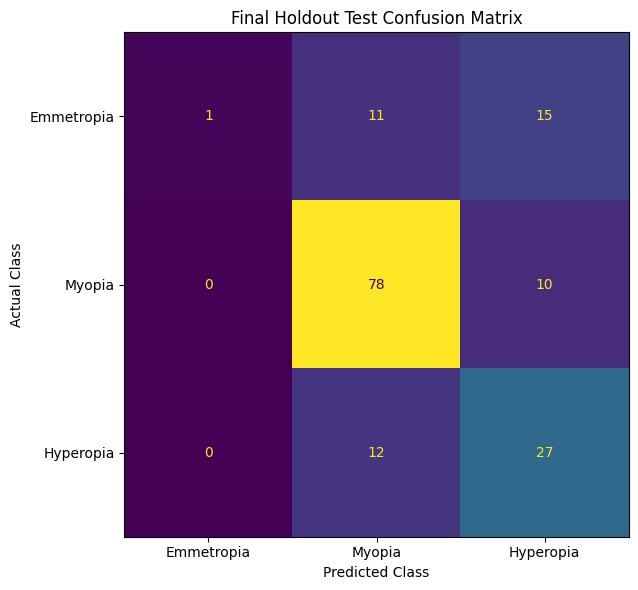

Confusion Matrix:
[[ 1 11 15]
 [ 0 78 10]
 [ 0 12 27]]


In [13]:
# ============================================================
# VISUALIZATION: FINAL HOLDOUT CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = ["Emmetropia", "Myopia", "Hyperopia"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(class_names))
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("Final Holdout Test Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

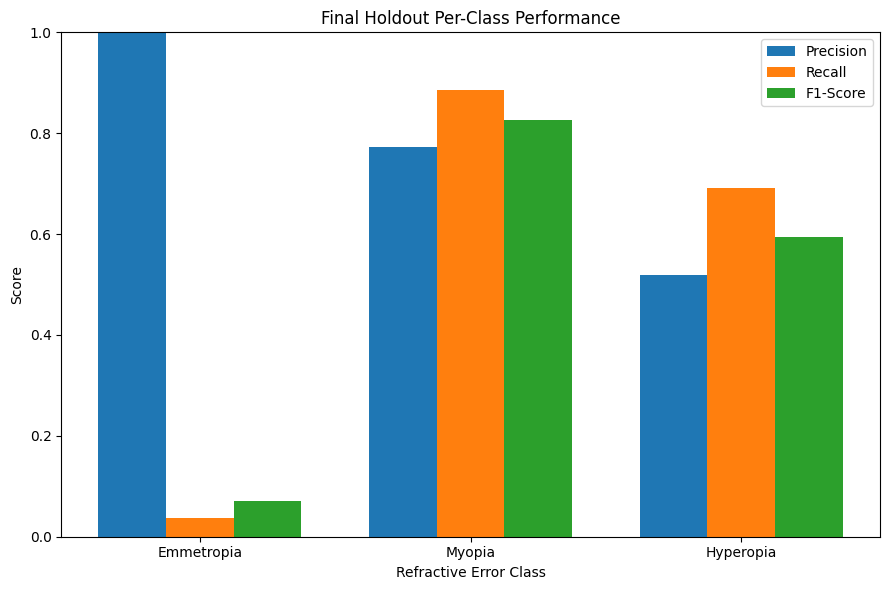

Emmetropia: Precision=1.0000, Recall=0.0370, F1=0.0714, Support=27
Myopia: Precision=0.7723, Recall=0.8864, F1=0.8254, Support=88
Hyperopia: Precision=0.5192, Recall=0.6923, F1=0.5934, Support=39


In [14]:
# ============================================================
# VISUALIZATION: FINAL HOLDOUT PER-CLASS PERFORMANCE
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    zero_division=0
)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

ax.bar(
    x,
    recall,
    width,
    label="Recall"
)

ax.bar(
    x + width,
    f1,
    width,
    label="F1-Score"
)

ax.set_title("Final Holdout Per-Class Performance")
ax.set_ylabel("Score")
ax.set_xlabel("Refractive Error Class")

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

# Also print the values for your Chapter 4 table
for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: "
        f"Precision={precision[i]:.4f}, "
        f"Recall={recall[i]:.4f}, "
        f"F1={f1[i]:.4f}, "
        f"Support={support[i]}"
    )

DEVELOPMENT/CV VS FINAL HOLDOUT
Accuracy             Development/CV: 0.7163 | Final Holdout: 0.6883
Macro Precision      Development/CV: 0.6024 | Final Holdout: 0.7638
Macro Recall         Development/CV: 0.6308 | Final Holdout: 0.5386
Macro F1             Development/CV: 0.5795 | Final Holdout: 0.4967
Balanced Accuracy    Development/CV: 0.6308 | Final Holdout: 0.5386


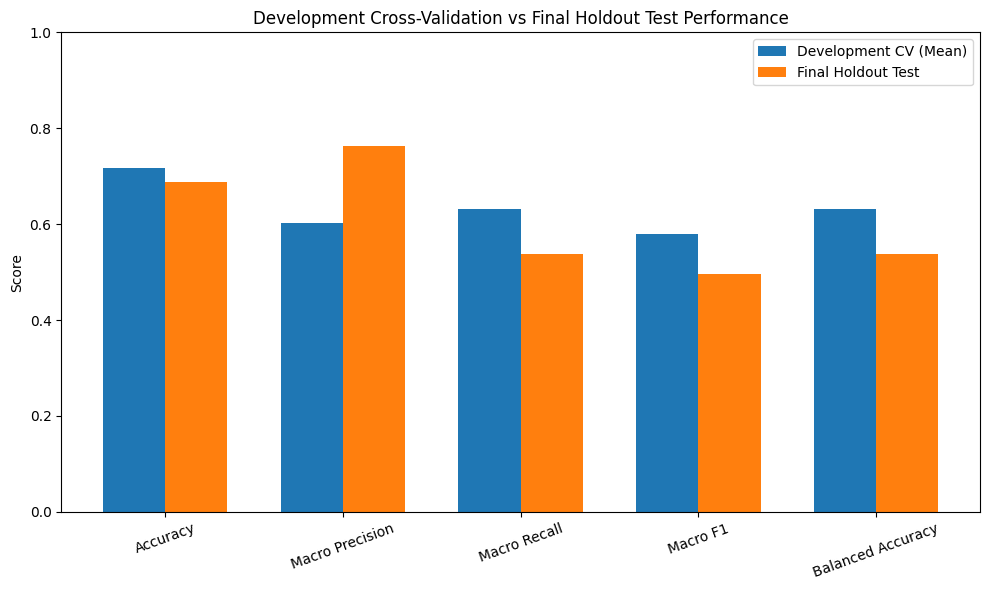

In [15]:
# ============================================================
# VISUALIZATION: DEVELOPMENT/CV VS FINAL HOLDOUT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# ------------------------------------------------------------
# 1. GET ACTUAL DEVELOPMENT/CV RESULTS
# ------------------------------------------------------------
# The Image + Age experiment stores its fold-level results
# in age_results["fold_results"], not age_results["summary"].

dev_results = age_results["fold_results"]

# Calculate the mean across the actual 10 CV folds
development_values = [
    dev_results["Accuracy"].mean(),
    dev_results["Macro Precision"].mean(),
    dev_results["Macro Recall"].mean(),
    dev_results["Macro F1"].mean(),
    dev_results["Balanced Accuracy"].mean()
]

# ------------------------------------------------------------
# 2. CALCULATE ACTUAL FINAL HOLDOUT RESULTS
# ------------------------------------------------------------
# y_true and y_pred must come from the final untouched
# 15% holdout evaluation.

holdout_values = [
    accuracy_score(y_true, y_pred),

    precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),

    recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),

    f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),

    balanced_accuracy_score(
        y_true,
        y_pred
    )
]

# ------------------------------------------------------------
# 3. DISPLAY THE ACTUAL VALUES
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy"
]

print("=" * 70)
print("DEVELOPMENT/CV VS FINAL HOLDOUT")
print("=" * 70)

for metric, dev, holdout in zip(
    metrics,
    development_values,
    holdout_values
):
    print(
        f"{metric:<20} "
        f"Development/CV: {dev:.4f} | "
        f"Final Holdout: {holdout:.4f}"
    )

# ------------------------------------------------------------
# 4. CREATE BAR CHART
# ------------------------------------------------------------

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    development_values,
    width,
    label="Development CV (Mean)"
)

ax.bar(
    x + width / 2,
    holdout_values,
    width,
    label="Final Holdout Test"
)

ax.set_title("Development Cross-Validation vs Final Holdout Test Performance")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# -----------------------------------------------------------------------------
# DEPLOYMENT EXPORT
# -----------------------------------------------------------------------------
# Save the trained final model and, when age is part of the selected
# configuration, its fitted scaler using the filenames expected by the app.
# Existing .pkl/.h5 artifacts are intentionally preserved in the repository.

import os
import shutil

MODEL_DIR = os.path.join(REPO_PATH, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

deployment_model_path = os.path.join(
    MODEL_DIR, f"best_{BEST_MODEL_NAME}_fold_1.keras"
)
shutil.copy2(
    f"/kaggle/working/{REPO_NAME}/artifacts/final_model.keras",
    deployment_model_path,
)

if USE_AGE:
    deployment_scaler_path = os.path.join(MODEL_DIR, "scaler_fold_1.joblib")
    shutil.copy2(
        f"/kaggle/working/{REPO_NAME}/artifacts/final_model_age_scaler.joblib",
        deployment_scaler_path,
    )
    print(f"Deployment scaler: {deployment_scaler_path}")

print(f"Deployment model: {deployment_model_path}")
print("Deployment export completed. Existing legacy .pkl/.h5 files were not removed.")

Deployment scaler: /kaggle/working/RefraScan/models/scaler_fold_1.joblib
Deployment model: /kaggle/working/RefraScan/models/best_resnet50_fold_1.keras
Deployment export completed. Existing legacy .pkl/.h5 files were not removed.
